In [1]:
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
from matplotlib.colors import PowerNorm,LogNorm, Normalize
import matplotlib.cm as mcm


from pathlib import Path
from datetime import datetime

import cmasher as cmr

from astropy.coordinates import SkyCoord
import astropy.units as u

import sunpy
import sunpy.map
from sunpy.physics.differential_rotation import differential_rotate

from scipy.ndimage import gaussian_filter1d, median_filter, zoom

import sys
sys.path.insert(0, '..')
from scripts.helpers import find_closest_hmi,find_closest_aia
from scripts.ribbon_map import RibbonMap as RM
from scripts.ribbon_map import RibbonCoords as RC
from scripts.ribbon_map import iris_reproject


In [2]:
import scienceplots
from sunpy.visualization.colormaps import color_tables as ct
plt.rcParams.update({'font.size': 14})
plt.style.use(['bright'])
plt.rcParams['font.family'] = 'Atkinson Hyperlegible Next'
sdoaia1600 = ct.aia_color_table(1600*u.angstrom)
sji1400cm = ct.iris_sji_color_table('1400')


In [3]:
time = '2014-04-18 12:51:52'
fn = '../auxiliary_data/hmi.m_45s.2014.04.18_12_52_30_TAI.magnetogram.fits'


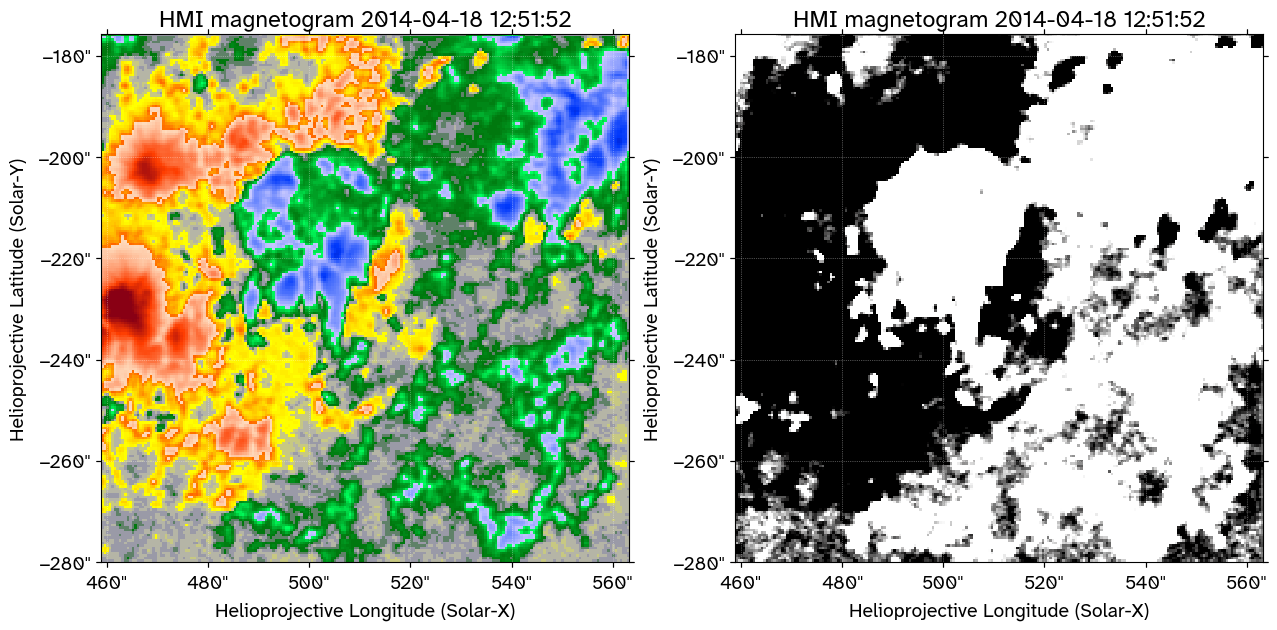

In [4]:
hmap = sunpy.map.Map(fn)
hmap = hmap.rotate(order=3)

xl, xr, yb, yt = 458, 562, -280, -176#450, 570, -280, -175

xlims_world = [xl, xr]*u.arcsec #small
ylims_world = [yb, yt]*u.arcsec

lb = SkyCoord(xlims_world[0],ylims_world[0],frame=hmap.coordinate_frame)
tr = SkyCoord(xlims_world[1],ylims_world[1],frame=hmap.coordinate_frame)

hmap = hmap.submap(lb, top_right=tr)
hmap = differential_rotate(hmap, time=time)

fig = plt.figure(figsize=(15,8))

ax = fig.add_subplot(121, projection=hmap)
hmap.plot(axes=ax, cmap="hmimag", norm=None, vmin=-1500.0, vmax=1500.0)
ax = fig.add_subplot(122, projection=hmap)
hmap.plot(axes=ax, cmap=cmr.neutral, norm=None, vmin=-10.0, vmax=10.0)

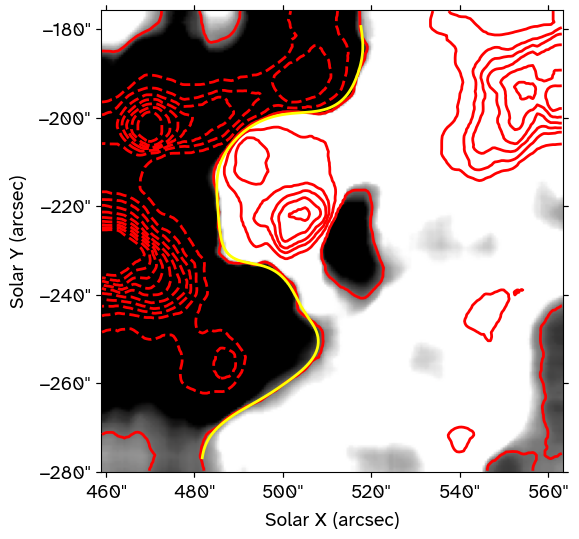

In [5]:
smoothed = median_filter(hmap.data, size=25) #10
smooth_map = sunpy.map.Map(smoothed, hmap.meta)

hmi_PIL = smooth_map.find_contours(0 * u.G)
ihmax = np.argmax([h.shape[0] for h in hmi_PIL])

pil = hmi_PIL[ihmax]

tx_smooth = gaussian_filter1d(pil.Tx.arcsec, sigma=10)
ty_smooth = gaussian_filter1d(pil.Ty.arcsec, sigma=10)

hmi_PIL_smooth = SkyCoord(tx_smooth * u.arcsec, ty_smooth * u.arcsec,
                          frame=smooth_map.coordinate_frame)

hmi_arcsec = np.column_stack([hmi_PIL_smooth.Tx.arcsec, hmi_PIL_smooth.Ty.arcsec])
np.savetxt('../auxiliary_data/hmi_pil_world_median.csv', hmi_arcsec, delimiter=',', header='Tx_arcsec,Ty_arcsec')


fig, ax = plt.subplots(figsize=(8,6), subplot_kw={'projection': smooth_map})
im = ax.imshow(smoothed, origin='lower', cmap=cmr.neutral, vmin=-10.0, vmax=10.0)

plt.contour(smoothed, levels=np.linspace(-1000, 1000, 21), colors='red', linewidths=2)


ax.plot_coord(hmi_PIL_smooth,color='yellow', linewidth=2)

ax.set_ylabel('Solar Y (arcsec)')
ax.set_xlabel('Solar X (arcsec)')

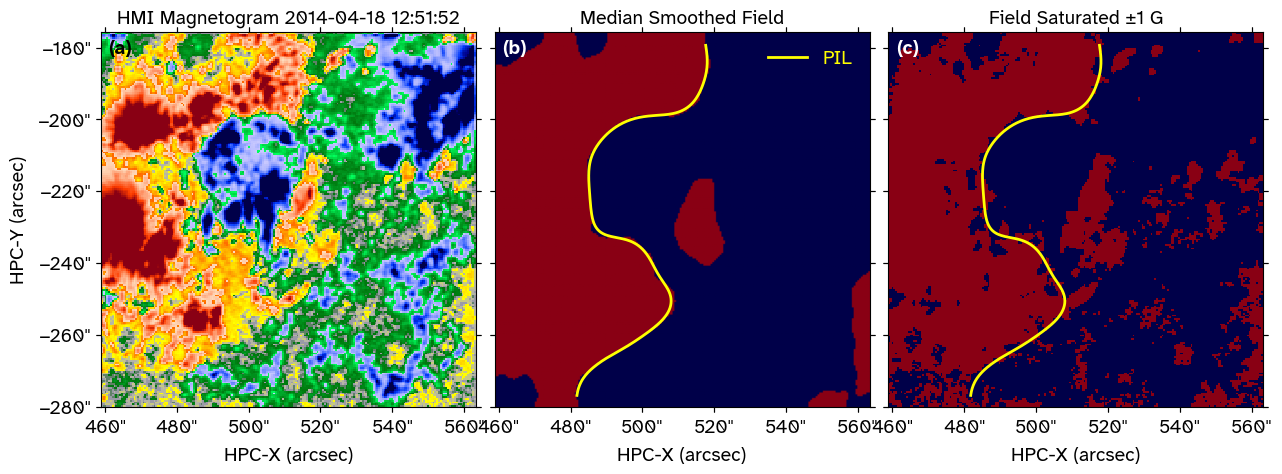

In [6]:
fig = plt.figure(figsize=(15, 8))

ax = fig.add_subplot(131, projection=hmap)
hmap.plot(axes=ax, cmap="hmimag", norm=None, vmin=-500.0, vmax=500.0)
ax.set_xlabel('HPC-X (arcsec)')
ax.set_ylabel('HPC-Y (arcsec)')
ax.set_title(f'HMI Magnetogram {hmap.date.strftime("%Y-%m-%d %H:%M:%S")}', fontsize=14)
ax.grid(False)
ax.text(0.02, 0.98, '(a)', transform=ax.transAxes, fontsize=14,
        va='top', ha='left', color='black', fontweight='bold')

ax = fig.add_subplot(132, projection=smooth_map)
im = ax.imshow(smoothed, origin='lower', cmap="hmimag", vmin=-.001, vmax=0.001)
ax.coords[1].set_ticklabel_visible(False)
ax.coords[1].set_axislabel('')
ax.set_xlabel('HPC-X (arcsec)')
ax.set_title('Median Smoothed Field', fontsize=14)
ax.plot_coord(hmi_PIL_smooth, color='yellow', linewidth=2, label='PIL')
ax.legend(loc='upper right', frameon=False, labelcolor='yellow')
ax.text(0.02, 0.98, '(b)', transform=ax.transAxes, fontsize=14,
        va='top', ha='left', color='white', fontweight='bold')

ax = fig.add_subplot(133, projection=hmap)
hmap.plot(axes=ax, cmap="hmimag", norm=None, vmin=-.001, vmax=0.001)
ax.coords[1].set_ticklabel_visible(False)
ax.coords[1].set_axislabel('')
ax.set_xlabel('HPC-X (arcsec)')
ax.set_title('Field Saturated ±1 G', fontsize=14)
ax.plot_coord(hmi_PIL_smooth, color='yellow', linewidth=2)
ax.grid(False)
ax.text(0.02, 0.98, '(c)', transform=ax.transAxes, fontsize=14,
        va='top', ha='left', color='white', fontweight='bold')

plt.subplots_adjust(wspace=0.05)
plt.savefig('../figures/hmi_pil_smoothing.png', dpi=300, bbox_inches='tight')


In [7]:
ref_map =  sunpy.map.Map('../auxiliary_data/aia_prep_1600_20140418_125152.fits')

xl, xr, yb, yt = 415, 585, -305, -150 # larger FOV to capture more of the ribbons

xlims_world = [xl, xr]*u.arcsec #small
ylims_world = [yb, yt]*u.arcsec

lb = SkyCoord(xlims_world[0],ylims_world[0],frame=ref_map.coordinate_frame)
tr = SkyCoord(xlims_world[1],ylims_world[1],frame=ref_map.coordinate_frame)

amap = ref_map.submap(lb, top_right=tr)

In [8]:
pil_world = SkyCoord(hmi_arcsec[:,0]*u.arcsec, hmi_arcsec[:,1]*u.arcsec, 
                     frame=ref_map.coordinate_frame)
separations = pil_world[1:].separation(pil_world[:-1]).to(u.arcsec)

arcsec = np.concatenate([[0], np.cumsum(separations.value)]) * u.arcsec
intensity = sunpy.map.sample_at_coords(amap, pil_world)

In [9]:
rmap,xarc,yarc = RM(amap, pil_world, xoffsets=[-45, 45], diff_rotate=True, ref_map=ref_map)
slice_coords, cross_arcsec = RC(amap, pil_world, xoffsets=[-45, 45], diff_rotate=True, ref_map=ref_map)

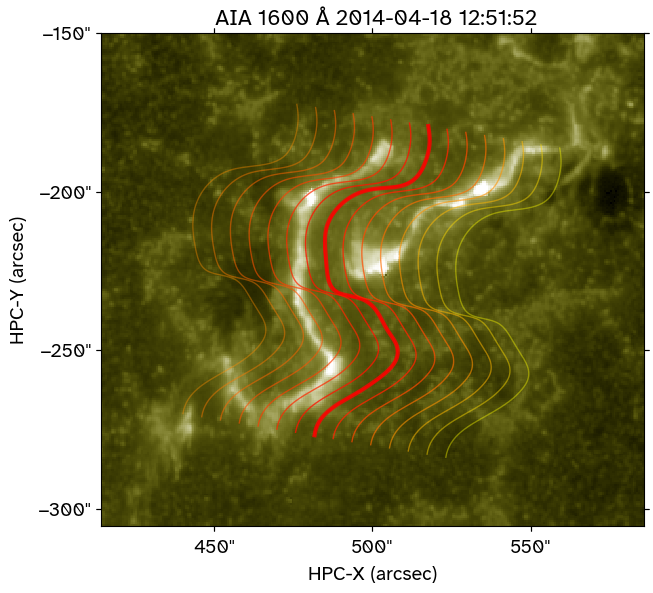

In [10]:
fig = plt.figure(figsize=(7, 7))
ax = plt.subplot(projection=amap)
amap.plot(axes=ax)
ax.grid(False)
ax.set_title(f' AIA 1600 Å {amap.date.strftime("%Y-%m-%d %H:%M:%S")}', fontsize=16)
ax.set_xlabel('HPC-X (arcsec)')
ax.set_ylabel('HPC-Y (arcsec)')

ax.plot_coord(pil_world, linewidth=3, color='red',alpha=0.8)

center_idx = np.argmin(np.abs(cross_arcsec))  
start = center_idx % 10                        
slices = slice_coords[start::10]
mid = (center_idx - start) // 10              

for i, sc in enumerate(slices):
    t = abs(i - mid) / max(mid, len(slices) - 1 - mid)
    lw = 1.4 - 0.8 * t
    alpha = 0.85 - 0.45 * t
    if i <= mid:
        frac = (mid - i) / max(mid, 1)
        color = (1.0, 0.55 * frac, 0.0)
    else:
        frac = (i - mid) / max(len(slices) - 1 - mid, 1)
        color = (1.0, frac, 0.0)
    ax.plot_coord(sc, linewidth=1.0, color=color, alpha=alpha)

fig.savefig('../figures/aia_pil_ribbons.png', dpi=300, bbox_inches='tight') 

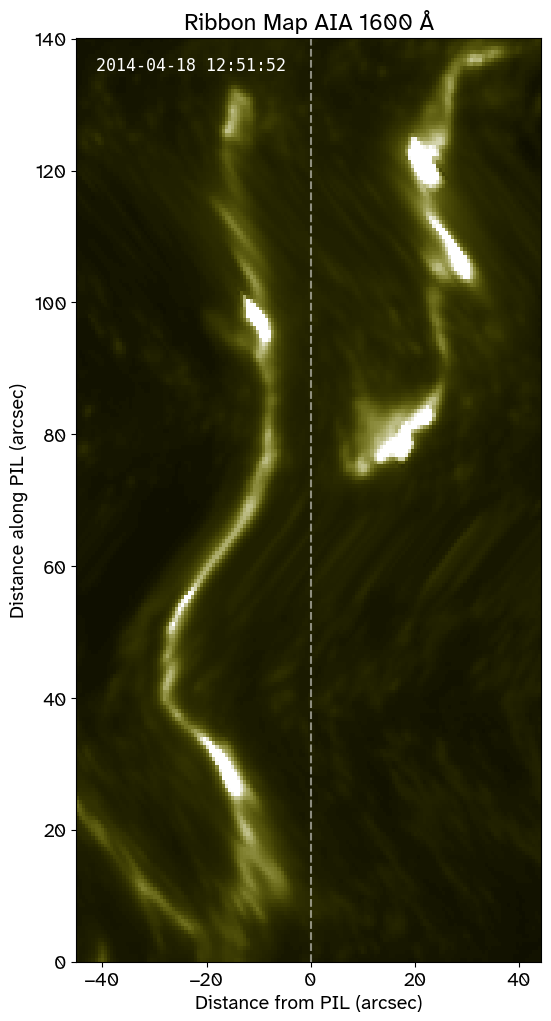

In [11]:
fig, ax = plt.subplots(figsize=(6, 12))

im = ax.imshow(rmap.T, aspect='auto', origin='lower',
               extent=[yarc[0], yarc[-1], xarc[-1], 0],
               cmap=sdoaia1600, vmin=0, vmax=10000, interpolation='None')

ax.axvline(0, color='white', linestyle='--', label='PIL location',alpha=0.5)

ax.set_ylabel('Distance along PIL (arcsec)')
ax.set_xlabel('Distance from PIL (arcsec)')
ax.set_title(f'Ribbon Map AIA 1600 Å')

ax.text(0.45, 0.98, amap.date.iso[:19], transform=ax.transAxes,
fontsize=12, va='top', ha='right',
fontfamily='monospace',color='white')
ax.invert_yaxis()

fig.savefig(f'../figures/aia1600_ribbon_map_{amap.date.iso}.png', dpi=300)


In [12]:
hmap = sunpy.map.Map(fn)
hmap = hmap.rotate(order=3)

xlims_world = [xl, xr]*u.arcsec 
ylims_world = [yb, yt]*u.arcsec

lb = SkyCoord(xlims_world[0],ylims_world[0],frame=hmap.coordinate_frame)
tr = SkyCoord(xlims_world[1],ylims_world[1],frame=hmap.coordinate_frame)

hmap = hmap.submap(lb, top_right=tr)

hmi_warped,h_xarc,h_yarc = RM(hmap, pil_world, xoffsets=[-45, 45], diff_rotate=False)

zoom_factors = (rmap.shape[0] / hmi_warped.shape[0], rmap.shape[1] / hmi_warped.shape[1])
hmi_warped_interp = zoom(hmi_warped, zoom_factors, order=3)

print(hmi_warped.shape, '->', hmi_warped_interp.shape, '(target:', rmap.shape, ')')


(179, 278) -> (150, 234) (target: (150, 234) )


In [13]:
zero_idx = np.argmin(np.abs(yarc))

def fwhm_bounds(prof, offset=0):
    peak_i = np.argmax(prof)
    half = prof[peak_i] / 2
    lo = peak_i
    while lo > 0 and prof[lo] > half:
        lo -= 1
    hi = peak_i
    while hi < len(prof) - 1 and prof[hi] > half:
        hi += 1
    return lo + offset, hi + offset

n_cols = rmap.shape[1]
a_arr, b_arr, c_arr, d_arr, mean_hmi_ab, mean_hmi_cd = [np.full(n_cols, np.nan) for _ in range(6)]

for idx in range(n_cols):
    profile = rmap[:, idx]

    # lower ribbon (below y=0): d=bottom, c=top
    d, c = fwhm_bounds(profile[:zero_idx])
    # upper ribbon (above y=0): b=bottom, a=top
    b, a = fwhm_bounds(profile[zero_idx:], zero_idx)

    a_arr[idx] = a
    b_arr[idx] = b
    c_arr[idx] = c
    d_arr[idx] = d
    mean_hmi_ab[idx] = np.median(hmi_warped_interp[b:a+1, idx])  # upper ribbon
    mean_hmi_cd[idx] = np.median(hmi_warped_interp[d:c+1, idx])  # lower ribbon


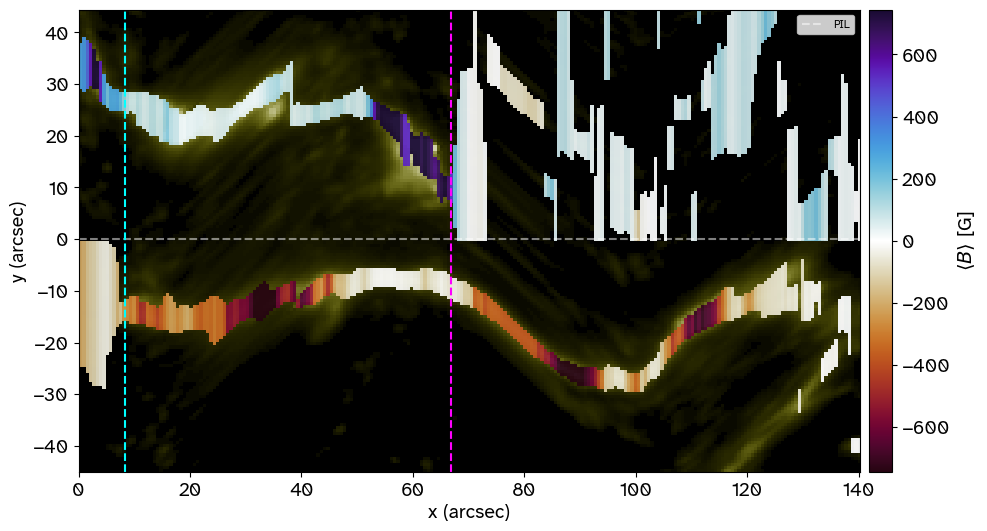

In [14]:

fig, ax = plt.subplots(figsize=(12, 6))

ax.imshow(rmap, aspect='auto', origin='lower',
          extent=[0, xarc[-1], yarc[0], yarc[-1]],
          cmap=sdoaia1600, vmin=300, vmax=10000, interpolation='None')

# Build RGBA overlay colored by mean B field
vlim = np.nanpercentile(np.abs(np.concatenate([mean_hmi_ab, mean_hmi_cd])), 95)
norm = Normalize(vmin=-vlim, vmax=vlim)
cmap_b = cmr.fusion

overlay = np.zeros((*rmap.shape, 4))
for idx in range(rmap.shape[1]):
    if np.isnan(a_arr[idx]):
        continue
    a, b, c, d = int(a_arr[idx]), int(b_arr[idx]), int(c_arr[idx]), int(d_arr[idx])
    overlay[b:a+1, idx] = (*cmap_b(norm(mean_hmi_ab[idx]))[:3], 0.95)
    overlay[d:c+1, idx] = (*cmap_b(norm(mean_hmi_cd[idx]))[:3], 0.95)

ax.imshow(overlay, aspect='auto', origin='lower',
          extent=[0, xarc[-1], yarc[0], yarc[-1]], interpolation='None')

ax.axhline(0, color='white', linestyle='--', alpha=0.5, label='PIL')
ax.set_xlabel('x (arcsec)')
ax.set_ylabel('y (arcsec)')

plt.colorbar(mcm.ScalarMappable(norm=norm, cmap=cmap_b),
             ax=ax, label=r'$\langle B \rangle$ [G]', pad=0.01)
ax.legend(fontsize=8)


xl,xr = 14, 111

ax.axvline(xarc[xl], color='cyan', linestyle='--', label='xl')
ax.axvline(xarc[xr], color='magenta', linestyle='--', label='xr')

rmap_crop = rmap[:, xl:xr]
xarc_crop = xarc[::-1][xl:xr]


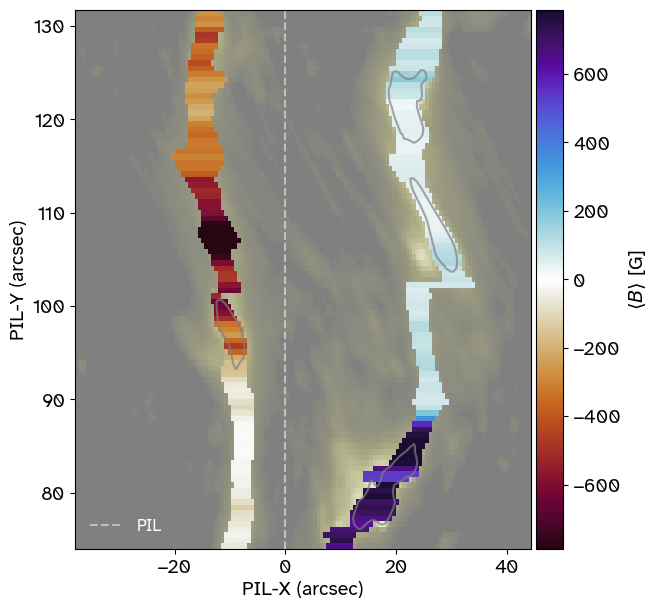

In [15]:
fig, ax = plt.subplots(figsize=(7, 7))  # swapped

ax.imshow(rmap_crop.T, aspect='auto', origin='lower',
          extent=[yarc[0], yarc[-1], xarc_crop[0], xarc_crop[-1]],  # swapped
          cmap=sdoaia1600, vmin=400, vmax=10000, interpolation='None', alpha=0.5)

vlim = np.nanpercentile(np.abs(np.concatenate([mean_hmi_ab[xl:xr], mean_hmi_cd[xl:xr]])), 95)
norm = Normalize(vmin=-vlim, vmax=vlim)
cmap_b = cmr.fusion

overlay = np.zeros((*rmap_crop.T.shape, 4))  # now (nx, ny, 4)
for i, idx in enumerate(range(xl, xr)):
    if np.isnan(a_arr[idx]):
        continue
    a, b, c, d = int(a_arr[idx]), int(b_arr[idx]), int(c_arr[idx]), int(d_arr[idx])
    overlay[i, b:a+1] = (*cmap_b(norm(mean_hmi_ab[idx]))[:3], 0.99)  # row↔col swapped
    overlay[i, d:c+1] = (*cmap_b(norm(mean_hmi_cd[idx]))[:3], 0.99)

ax.imshow(overlay, aspect='auto', origin='lower',
          extent=[yarc[0], yarc[-1], xarc_crop[0], xarc_crop[-1]],  # swapped
          interpolation='None')

ax.set_ylabel('PIL-Y (arcsec)')
ax.set_xlabel('PIL-X (arcsec)')

ax.axvline(0, color='white', linestyle='--', label='PIL',alpha=0.5)


plt.colorbar(mcm.ScalarMappable(norm=norm, cmap=cmap_b),
             ax=ax, label=r'$\langle B \rangle$ [G]', pad=0.01)
ax.legend(fontsize=12, frameon=False, labelcolor='white', loc='lower left')

contours = ax.contour(rmap_crop.T, levels=[7500],
                      extent=[yarc[0], yarc[-1], xarc_crop[0], xarc_crop[-1]],
                      colors='grey', linewidths=1.5, alpha=0.7,
                      origin='lower')

ax.set_xlim(-38)  # was set_ylim
ax.invert_yaxis()

fig.savefig(f'../figures/aia1600_ribbon_map_zoom_{amap.date.iso}.png', dpi=300, bbox_inches='tight')

In [16]:
ny, nx = rmap_crop.shape

data = np.column_stack([
    a_arr[xl:xr] / ny,
    b_arr[xl:xr] / ny,
    c_arr[xl:xr] / ny,
    d_arr[xl:xr] / ny,
    mean_hmi_ab[xl:xr],
    mean_hmi_cd[xl:xr],
])

np.savetxt(
    '../auxiliary_data/ribbon_bounds.txt',
    data,
    header='a  b  c  d  mean_hmi_ab  mean_hmi_cd',
    fmt='%.6f',
)
print(f"Saved {data.shape[0]} rows to ribbon_bounds.txt")

np.save('../auxiliary_data/rmap_crop.npy', rmap_crop)
print(f"Saved rmap_crop {rmap_crop.shape} to auxiliary_data/rmap_crop.npy")

Saved 97 rows to ribbon_bounds.txt
Saved rmap_crop (150, 97) to auxiliary_data/rmap_crop.npy


INFO: Missing metadata for solar radius: assuming the standard radius of the photosphere. [sunpy.map.mapbase]


For frame 'heliographic_stonyhurst' the following metadata is missing: hglt_obs,hgln_obs
For frame 'heliographic_carrington' the following metadata is missing: crln_obs,crlt_obs
 [sunpy.map.mapbase]


Text(0.5, 1.0, 'IRIS/SJI 1400 Å 2014-04-18 12:51:43.368')

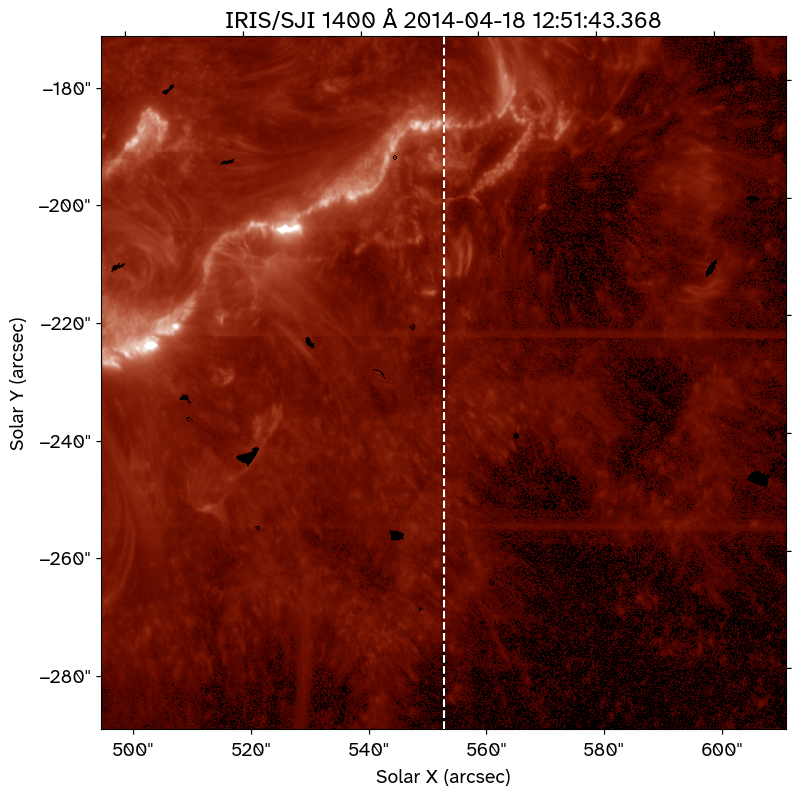

In [17]:
sji_map = sunpy.map.Map('../auxiliary_data/SJI_1400_maps038.fits')

fig = plt.figure(figsize=(9,9))
ax = fig.add_subplot(projection=sji_map)
sji_map.plot(axes=ax,norm=LogNorm(vmin=1.0))

ax.coords.grid(False)
ax.set_xlabel('Solar X (arcsec)')
ax.set_ylabel('Solar Y (arcsec)')
ax.set_title(f"SJI 1400{chr(197)} {sji_map.date}")

slit_px = sji_map.meta['crpix1']
ax.axvline(slit_px,color='white',linestyle='dashed')
date_str = sji_map.date.value.split('T')
ax.set_title(f'IRIS/SJI 1400 Å {date_str[0]} {date_str[1]}')

INFO: Missing metadata for solar radius: assuming the standard radius of the photosphere. [sunpy.map.mapbase]
INFO: Missing metadata for solar radius: assuming the standard radius of the photosphere. [sunpy.map.mapbase]


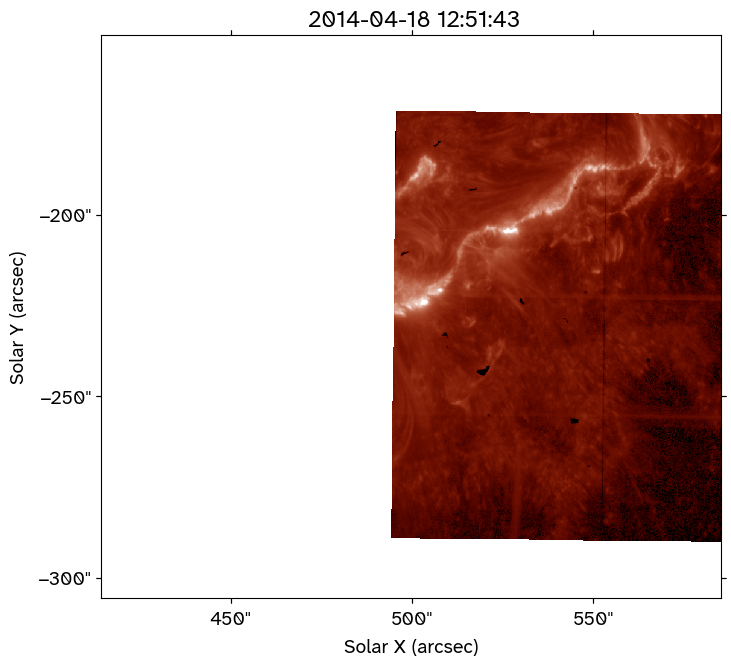

In [18]:
iris_reproj = iris_reproject(sji_map, amap)

fig = plt.figure(figsize=(8,8))
ax = fig.add_subplot(projection=iris_reproj)
iris_reproj.plot(axes=ax,norm=LogNorm())
ax.coords.grid(False)
ax.set_xlabel('Solar X (arcsec)')
ax.set_ylabel('Solar Y (arcsec)')

In [19]:
pil_world = SkyCoord(hmi_arcsec[:,0]*u.arcsec, hmi_arcsec[:,1]*u.arcsec, 
                     frame=iris_reproj.coordinate_frame)
separations = pil_world[1:].separation(pil_world[:-1]).to(u.arcsec)

arcsec = np.concatenate([[0], np.cumsum(separations.value)]) * u.arcsec
intensity = sunpy.map.sample_at_coords(iris_reproj, pil_world)

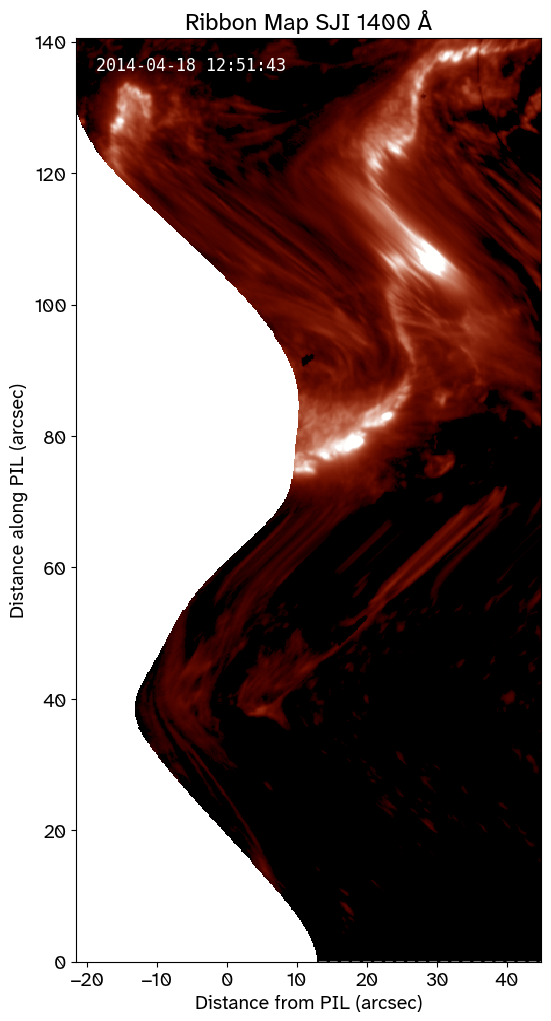

In [20]:
rmap_sji,xarc_sji,yarc_sji = RM(iris_reproj, pil_world, xoffsets=[-45, 45], diff_rotate=False, ref_map=iris_reproj)


fig, ax = plt.subplots(figsize=(6, 12))
im = ax.imshow(rmap_sji.T/sji_map.exposure_time.value, aspect='auto', origin='lower',
               extent=[yarc_sji[0], yarc_sji[-1], xarc_sji[-1], xarc_sji[0]],
               cmap=sji1400cm, norm=LogNorm(vmin=10.0, vmax=3000), interpolation='None')

ax.axhline(0, color='white', linestyle='--', label='PIL location',alpha=0.5)

ax.set_ylabel('Distance along PIL (arcsec)')
ax.set_xlabel('Distance from PIL (arcsec)')
ax.set_title(f'Ribbon Map SJI 1400 Å')

ax.text(0.45, 0.98, iris_reproj.date.iso[:19], transform=ax.transAxes,
        fontsize=12, va='top', ha='right',
        fontfamily='monospace',color='white')

ax.set_xlim(-21.5)  # was set_ylim


ax.invert_yaxis()

53 400


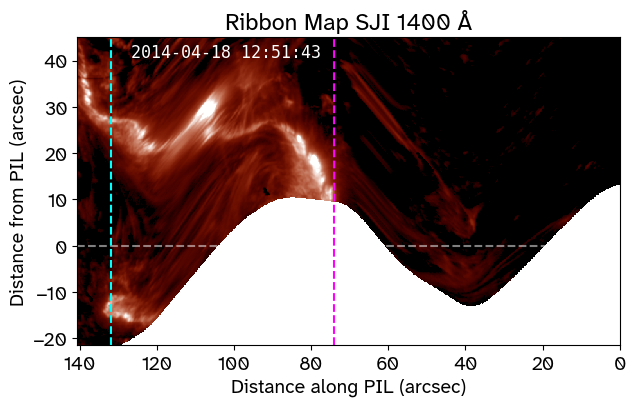

In [21]:
xarc_sji = xarc_sji[::-1]

fig, ax = plt.subplots(figsize=(7, 4))
im = ax.imshow(rmap_sji/sji_map.exposure_time.value, aspect='auto', origin='lower',
               extent=[xarc_sji[0], xarc_sji[-1], yarc_sji[0], yarc_sji[-1]],
               cmap=sji1400cm, norm=LogNorm(vmin=10.0, vmax=3000), interpolation='None')

ax.axhline(0, color='white', linestyle='--', label='PIL location',alpha=0.5)

ax.set_xlabel('Distance along PIL (arcsec)')
ax.set_ylabel('Distance from PIL (arcsec)')
ax.set_title(f'Ribbon Map SJI 1400 Å')

ax.text(0.45, 0.98, iris_reproj.date.iso[:19], transform=ax.transAxes,
        fontsize=12, va='top', ha='right',
        fontfamily='monospace',color='white')

ax.set_ylim(-21.5)  # was set_ylim

xl,xr = np.argmin(np.abs(xarc_sji-xarc_crop[0])),np.argmin(np.abs(xarc_sji-xarc_crop[-1]))
print(xl,xr)

ax.axvline(xarc_sji[xl], color='cyan', linestyle='--', label='xl')
ax.axvline(xarc_sji[xr], color='magenta', linestyle='--', label='xr')

rmap_sji_crop = rmap_sji[:, xl:xr]
xarc_sji_crop = xarc_sji[xl:xr]


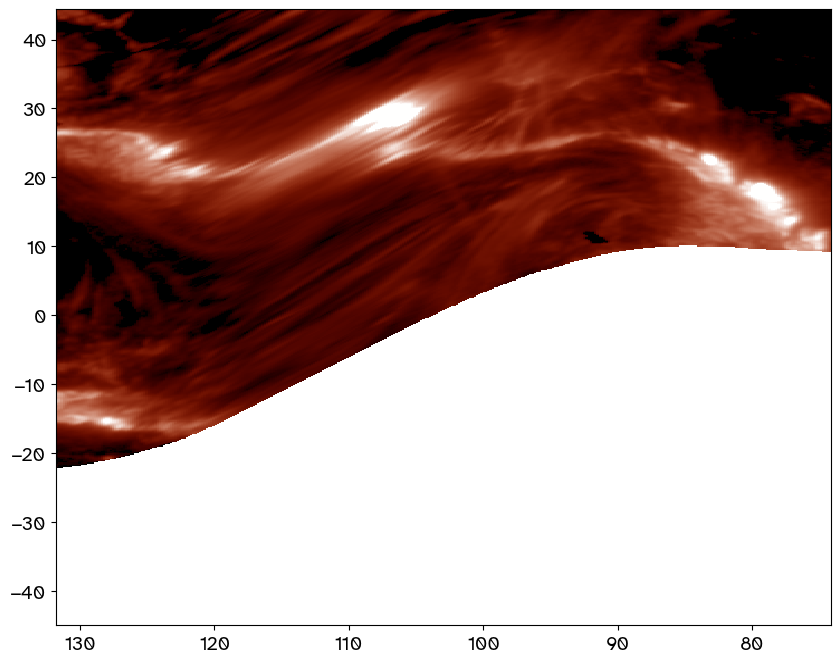

In [22]:
fig, ax = plt.subplots(figsize=(10, 8))

ax.imshow(rmap_sji_crop/sji_map.exposure_time.value, aspect='auto', origin='lower',
          extent=[xarc_sji_crop[0], xarc_sji_crop[-1], yarc[0], yarc[-1]],
          cmap=sji1400cm,  norm=LogNorm(vmin=10.0, vmax=3000), interpolation='None')

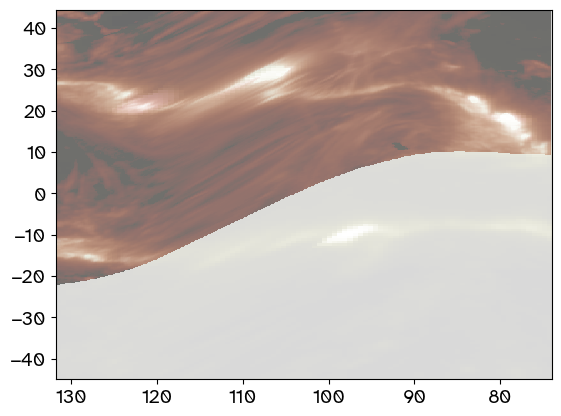

In [23]:
plt.imshow(rmap_sji_crop/sji_map.exposure_time.value, aspect='auto', origin='lower',
           extent=[xarc_sji_crop[0], xarc_sji_crop[-1], yarc[0], yarc[-1]],
           cmap=sji1400cm, norm=LogNorm(vmin=10.0, vmax=3000), interpolation='None', alpha=0.5)

plt.imshow(rmap_crop, aspect='auto', origin='lower',
           extent=[xarc_crop[0], xarc_crop[-1], yarc[0], yarc[-1]],
           cmap=sdoaia1600, interpolation='None', alpha=0.15)

In [24]:
np.save('../auxiliary_data/rmap_sji_crop.npy', rmap_sji_crop)
print(f"Saved rmap_sji_crop {rmap_sji_crop.shape} to auxiliary_data/rmap_sji_crop.npy")

indices = np.argmin(np.abs(xarc_sji_crop[:, None] - xarc_crop[None, :]), axis=1)

np.savez('../auxiliary_data/rmap_sji_data.npz', rmap_sji_crop=rmap_sji_crop, indices=indices)
print(f"Saved rmap_sji_data with rmap_sji_crop {rmap_sji_crop.shape} and indices {indices.shape} to auxiliary_data/rmap_sji_data.npz")

Saved rmap_sji_crop (542, 347) to auxiliary_data/rmap_sji_crop.npy
Saved rmap_sji_data with rmap_sji_crop (542, 347) and indices (347,) to auxiliary_data/rmap_sji_data.npz


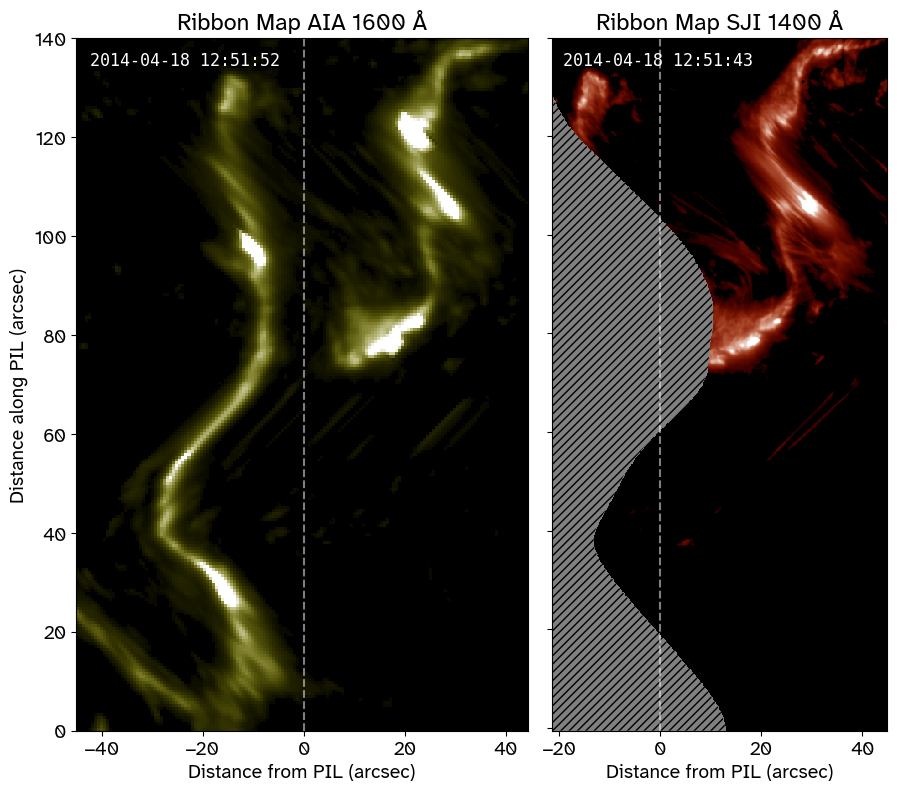

In [25]:
x1_range = float(yarc[-1] - yarc[0])
x2_lo = -21.5
x2_range = float(yarc_sji[-1] - x2_lo)

fig, (ax1, ax2) = plt.subplots(
    1, 2,
    figsize=(6 * (x1_range + x2_range) / x1_range, 9),
    gridspec_kw={'width_ratios': [x1_range, x2_range], 'wspace': 0.06},
)

# ── Left: AIA 1600 ────────────────────────────────────────────────────────────
im1 = ax1.imshow(rmap.T, aspect='auto', origin='lower',
                 extent=[yarc[0], yarc[-1], xarc[-1], 0],
                 cmap=sdoaia1600, vmin=400, vmax=10000, interpolation='None')

ax1.axvline(0, color='white', linestyle='--', label='PIL location', alpha=0.5)
ax1.set_ylabel('Distance along PIL (arcsec)')
ax1.set_xlabel('Distance from PIL (arcsec)')
ax1.set_title('Ribbon Map AIA 1600 Å')
ax1.text(0.45, 0.98, amap.date.iso[:19], transform=ax1.transAxes,
         fontsize=12, va='top', ha='right', fontfamily='monospace', color='white')
ax1.invert_yaxis()

# ── Right: SJI 1400 ───────────────────────────────────────────────────────────
sji_data = rmap_sji.T / sji_map.exposure_time.value

# Make NaN transparent so we can draw the hatch on top
sji_cmap = sji1400cm.copy()
sji_cmap.set_bad(alpha=0.0)
ax2.set_facecolor('grey')

im2 = ax2.imshow(sji_data, aspect='auto', origin='lower',
                 extent=[yarc_sji[0], yarc_sji[-1], xarc_sji[-1], xarc_sji[0]],
                 cmap=sji_cmap, norm=LogNorm(vmin=30.0, vmax=5000), interpolation='None')

# Black hatch overlay for NaN regions
nan_mask = np.isnan(sji_data)
y_centers = np.linspace(yarc_sji[0],  yarc_sji[-1],  sji_data.shape[1])
x_centers = np.linspace(xarc_sji[-1], xarc_sji[0],  sji_data.shape[0])
ax2.contourf(y_centers, x_centers, nan_mask.astype(float),
             levels=[0.5, 1.5], hatches=['////'], colors='black', alpha=0.0)

ax2.axvline(0, color='white', linestyle='--', label='PIL location', alpha=0.5)
ax2.set_xlabel('Distance from PIL (arcsec)')
ax2.set_title('Ribbon Map SJI 1400 Å')
ax2.text(0.6, 0.98, iris_reproj.date.iso[:19], transform=ax2.transAxes,
         fontsize=12, va='top', ha='right', fontfamily='monospace', color='white')
ax2.set_xlim(x2_lo, yarc_sji[-1])
ax2.tick_params(labelleft=False)   # ← suppress y tick labels
ax2.invert_yaxis()

fig.savefig(f'../figures/aia1600_sji1400_ribbon_map_comparison_{amap.date.iso}.png', dpi=300, bbox_inches='tight')